In [1]:
# Cell 1 — Imports and configuration

import sys
import time
from pathlib import Path
from importlib.metadata import version

import numpy as np
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats

from slmsuite.hardware.cameras.alliedvision import AlliedVision
from slmsuite.hardware.slms.meadowlark import Meadowlark


# Plotting
set_matplotlib_formats("retina")

plt.style.use(
    "https://raw.githubusercontent.com/"
    "ksingh1121/python-plot-style/main/physics.mplstyle"
)


# Meadowlark
SDK_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK"
)

FAN_LUT_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM"
    r"\LUT from Fan\759nm_roomtemp_global"
    r"\759nm_roomtemp_global"
    r"\759nm_rommtemp_global.lut"
)

LINEAR_LUT_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI"
    r"\LUT Files\19x12_8bit_linearVoltage.lut"
)


# Camera
CAMERA_SERIAL = "015C2"
CAMERA_PITCH_UM = 2.4


# Calibration
REFERENCE_GRAY = 255
PIXELS_PER_STRIPE = 8


print("=== 759-nm LUT calibration — intensity locked ===")
print("Python     :", sys.version.split()[0])
print("slmsuite   :", version("slmsuite"))
print("NumPy      :", np.__version__)

print()
print("SDK exists        :", SDK_PATH.exists())
print("Fan LUT exists    :", FAN_LUT_PATH.exists())
print("Linear LUT exists :", LINEAR_LUT_PATH.exists())

assert SDK_PATH.exists()
assert FAN_LUT_PATH.exists()
assert LINEAR_LUT_PATH.exists()

=== 759-nm LUT calibration — intensity locked ===
Python     : 3.12.10
slmsuite   : 0.4.1
NumPy      : 2.5.1

SDK exists        : True
Fan LUT exists    : True
Linear LUT exists : True


In [6]:
# Cell 2 — Initialize Allied Vision camera

cam = AlliedVision(
    serial=CAMERA_SERIAL,
    pitch_um=CAMERA_PITCH_UM,
    verbose=True,
)

print("\n=== Camera ready ===")
print("Name       :", cam.name)
print("Shape      :", cam.shape)
print("Pixel pitch:", cam.pitch_um, "um")

vmbpy initializing... success
Looking for cameras... success
vmbpy sn '015C2' initializing... success

=== Camera ready ===
Name       : 015C2
Shape      : (3672, 5496)
Pixel pitch: [2.4 2.4] um


=== Camera acquisition test ===
Image shape : (3672, 5496)
dtype       : uint8
Minimum     : 3
Maximum     : 39
Pixels @255 : 0


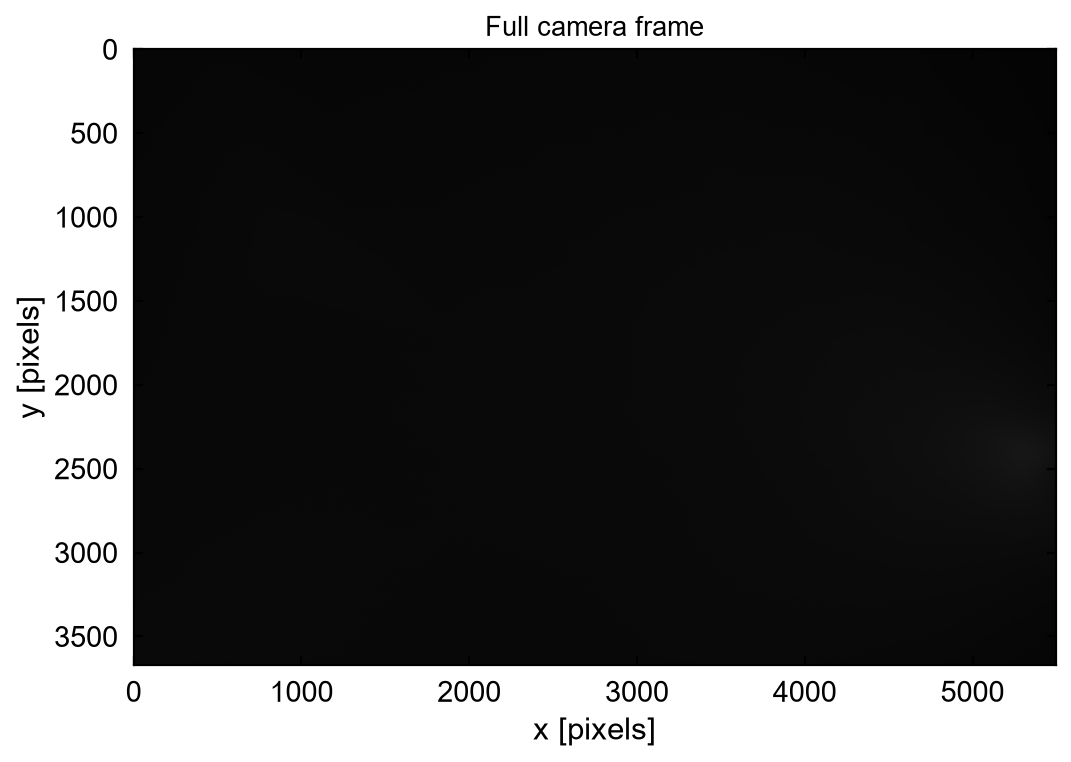

In [7]:
# Cell 3 — Verify one real camera acquisition

image = cam.get_image(
    timeout_s=3,
    transform=False,
)

print("=== Camera acquisition test ===")
print("Image shape :", image.shape)
print("dtype       :", image.dtype)
print("Minimum     :", image.min())
print("Maximum     :", image.max())
print("Pixels @255 :", np.count_nonzero(image == 255))

plt.figure(figsize=(8, 5))
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title("Full camera frame")
plt.xlabel("x [pixels]")
plt.ylabel("y [pixels]")
plt.show()

In [8]:
# Cell 4 — Initialize Meadowlark SLM

slm = Meadowlark(
    slm_number=1,
    sdk_path=str(SDK_PATH),
    lut_path=str(FAN_LUT_PATH),
    wav_um=0.759,
    verbose=True,
)

print("\n=== SLM ready ===")
print("Name       :", slm.name)
print("Shape      :", slm.shape)
print("Bit depth  :", slm.bitdepth)
print("Wavelength :", slm.wav_um, "um")
print("Pixel pitch:", slm.pitch_um, "um")

Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...
=== SLM ready ===
Name       : Meadowlark HDMI
Shape      : (1200, 1920)
Bit depth  : 8
Wavelength : 0.759 um
Pixel pitch: [8. 8.] um


In [9]:
# Cell 5 — Load Meadowlark linear-voltage LUT
#
# Do NOT recreate the SLM object.
# We simply change the LUT in the already-open SDK.

slm.load_lut(str(LINEAR_LUT_PATH))

print("\n=== Linear LUT loaded ===")
print(LINEAR_LUT_PATH)


=== Linear LUT loaded ===
C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\LUT Files\19x12_8bit_linearVoltage.lut


In [16]:
# Cell 6 — Display binary calibration grating

TEST_GRAY = 128

ny, nx = slm.shape
x = np.arange(nx)

stripe_line = np.where(
    (x // PIXELS_PER_STRIPE) % 2 == 0,
    REFERENCE_GRAY,
    TEST_GRAY,
).astype(np.uint8)

binary_grating = np.tile(
    stripe_line,
    (ny, 1)
)

print("=== Calibration grating ===")
print("Shape        :", binary_grating.shape)
print("dtype        :", binary_grating.dtype)
print("Unique values:", np.unique(binary_grating))
print("First 40 pixels:")
print(binary_grating[0, :40])

slm.set_phase(
    binary_grating,
    settle=True
)

print("\nGrating written to SLM.")

=== Calibration grating ===
Shape        : (1200, 1920)
dtype        : uint8
Unique values: [128 255]
First 40 pixels:
[255 255 255 255 255 255 255 255 128 128 128 128 128 128 128 128 255 255
 255 255 255 255 255 255 128 128 128 128 128 128 128 128 255 255 255 255
 255 255 255 255]

Grating written to SLM.


In [11]:
print("SLM display dtype :", slm.display.dtype)
print("Display values    :", np.unique(slm.display))
print(
    "Exact pattern sent:",
    np.array_equal(slm.display, binary_grating)
)

SLM display dtype : uint8
Display values    : [128 255]
Exact pattern sent: True


In [17]:
cam.live(
    activate=True,
    widgets=True,
    cmap="gray",
    min=0,
    max=255,
    scale=2,
    crosshair=True,
)

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00*\xf0\x00\x00\x1c\xb0\x08\x06\x00\x00\x00\xf5@\xc2\x1…

In [19]:
# Stop live camera streaming
cam.live(activate=False)

print("Live view stopped.")

Live view stopped.


In [ ]:
# Set camera exposure
cam.set_exposure(200e-6)   # 0.500 ms

0.000112181

=== Single-frame check ===
Image shape       : (3672, 5496)
Minimum           : 0
Maximum           : 215
Pixels at 255     : 0
Saturated fraction: 0.000000 %


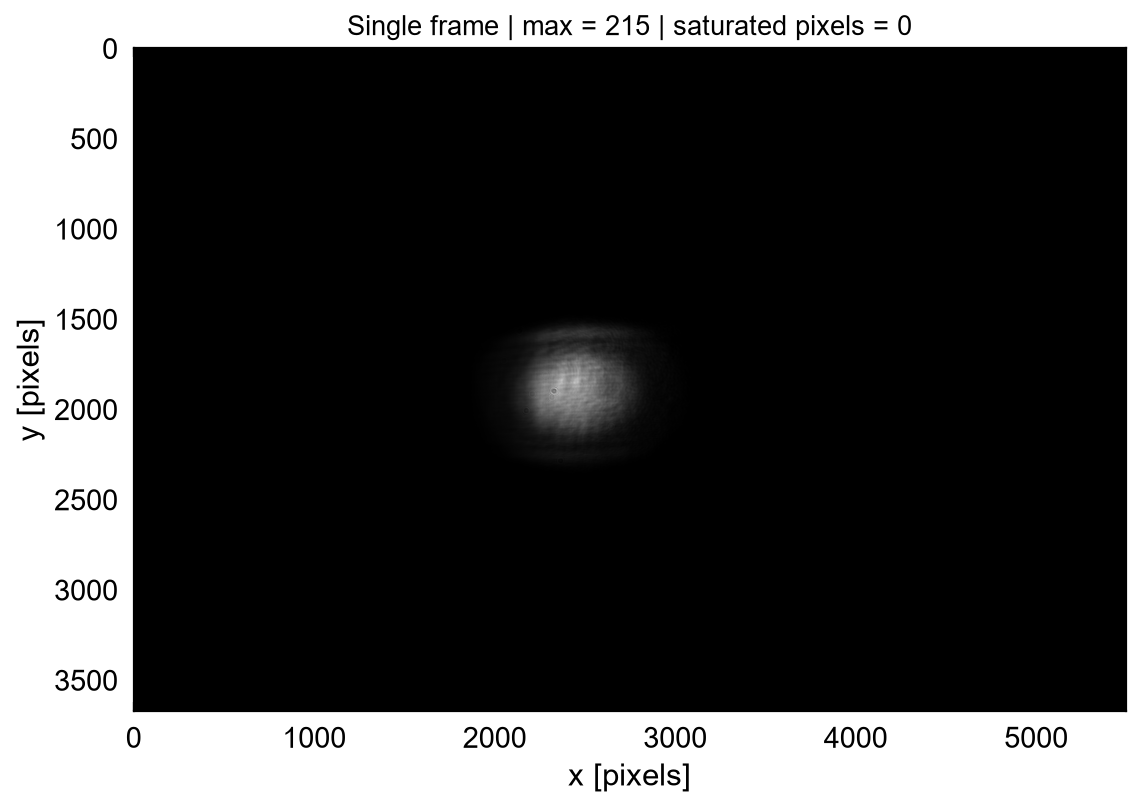

In [35]:
# Grab one static frame and check saturation

image = cam.get_image(
    timeout_s=3,
    transform=False,
)

n_sat = np.count_nonzero(image == 255)
sat_fraction = n_sat / image.size

print("=== Single-frame check ===")
print("Image shape       :", image.shape)
print("Minimum           :", image.min())
print("Maximum           :", image.max())
print("Pixels at 255     :", n_sat)
print("Saturated fraction:", f"{100 * sat_fraction:.6f} %")

plt.figure(figsize=(8, 6))
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title(
    f"Single frame | max = {image.max()} | saturated pixels = {n_sat}"
)
plt.xlabel("x [pixels]")
plt.ylabel("y [pixels]")
plt.show()

In [38]:
# Characterize camera background at the CURRENT exposure/gain

dark = cam.get_image(
    timeout_s=3,
    transform=False,
)

print("=== Dark-frame statistics ===")
print("Minimum       :", dark.min())
print("Median        :", np.median(dark))
print("Mean          :", dark.mean())
print("99th percentile:", np.percentile(dark, 99))
print("99.9 percentile:", np.percentile(dark, 99.9))
print("Maximum       :", dark.max())

=== Dark-frame statistics ===
Minimum       : 0
Median        : 0.0
Mean          : 1.5856253547836732e-06
99th percentile: 0.0
99.9 percentile: 0.0
Maximum       : 32


In [39]:
# Restore calibration grating

slm.set_phase(binary_grating, settle=True)

print("Calibration grating restored.")
print("Display values:", np.unique(slm.display))

Calibration grating restored.
Display values: [128 255]


=== Isolated diffraction order ===
Image shape          : (3672, 5496)
Peak position (x, y) : (np.int64(2349), np.int64(1908))
Peak value           : 213
Pixels at 255        : 0


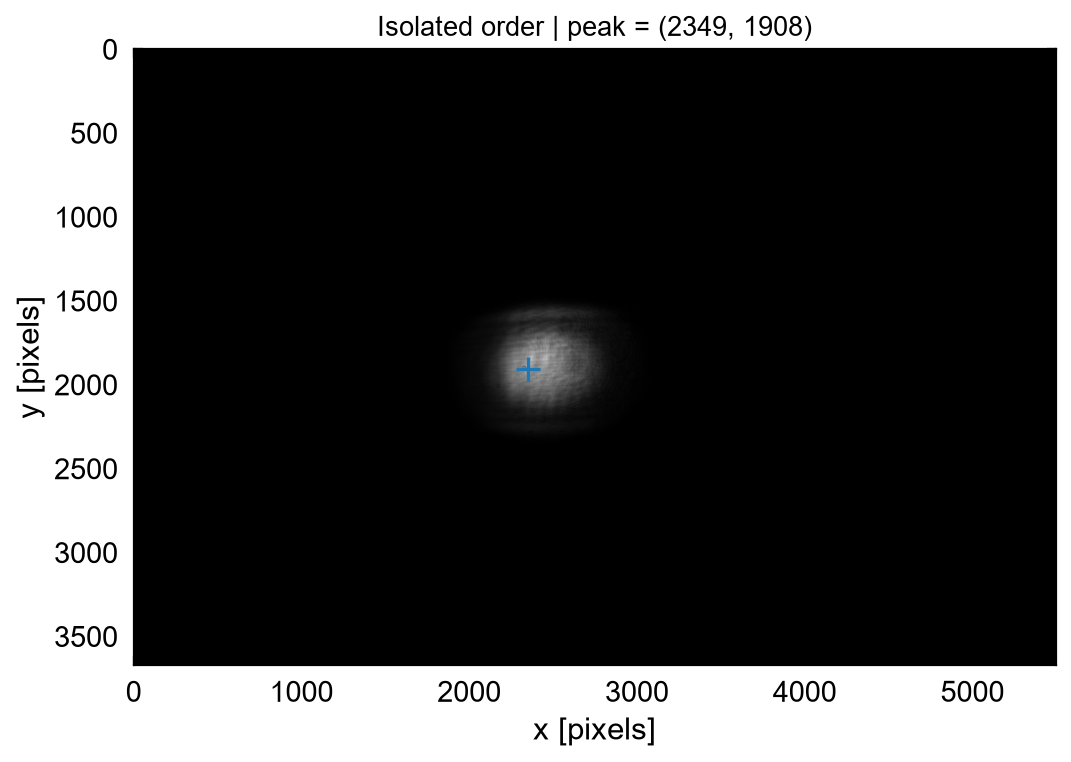

In [41]:
# Cell 8 — Locate the isolated ±1 diffraction order

image = cam.get_image(
    timeout_s=3,
    transform=False,
)

peak_y, peak_x = np.unravel_index(
    np.argmax(image),
    image.shape
)

print("=== Isolated diffraction order ===")
print("Image shape          :", image.shape)
print("Peak position (x, y) :", (peak_x, peak_y))
print("Peak value           :", image[peak_y, peak_x])
print("Pixels at 255        :", np.count_nonzero(image == 255))

plt.figure(figsize=(8, 5))
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.scatter(peak_x, peak_y, marker="+", s=120)
plt.title(f"Isolated order | peak = ({peak_x}, {peak_y})")
plt.xlabel("x [pixels]")
plt.ylabel("y [pixels]")
plt.show()

=== 1200 × 1200 ROI ===
Requested WOI       : (1748, 1200, 1308, 1200)
Actual image shape  : (1200, 1200)
Local peak (x, y)   : (np.int64(601), np.int64(600))
Peak value          : 217
Pixels at 255       : 0


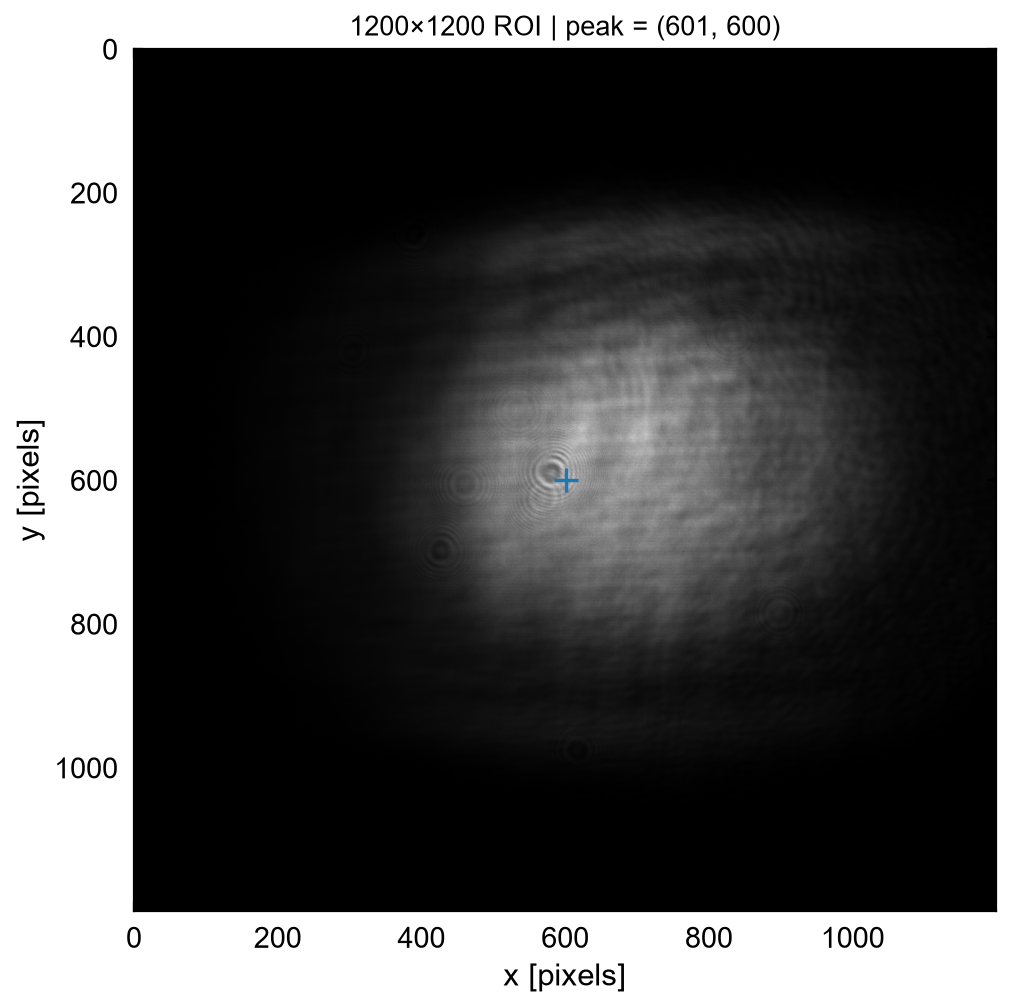

In [42]:
# Cell 9 — Set 1200 × 1200 hardware ROI around isolated order

ROI_SIZE = 1200

# Chosen so global peak (2349, 1908)
# becomes approximately local (601, 600)
ROI_X0 = 1748
ROI_Y0 = 1308

cam.set_woi(
    (ROI_X0, ROI_SIZE, ROI_Y0, ROI_SIZE)
)

# Acquire one image to verify actual hardware ROI
image_roi = cam.get_image(
    timeout_s=3,
    transform=False,
)

local_peak_y, local_peak_x = np.unravel_index(
    np.argmax(image_roi),
    image_roi.shape
)

print("=== 1200 × 1200 ROI ===")
print("Requested WOI       :", (ROI_X0, ROI_SIZE, ROI_Y0, ROI_SIZE))
print("Actual image shape  :", image_roi.shape)
print("Local peak (x, y)   :", (local_peak_x, local_peak_y))
print("Peak value          :", image_roi[local_peak_y, local_peak_x])
print("Pixels at 255       :", np.count_nonzero(image_roi == 255))

plt.figure(figsize=(7, 7))
plt.imshow(image_roi, cmap="gray", vmin=0, vmax=255)
plt.scatter(local_peak_x, local_peak_y, marker="+", s=120)
plt.title(
    f"1200×1200 ROI | peak = ({local_peak_x}, {local_peak_y})"
)
plt.xlabel("x [pixels]")
plt.ylabel("y [pixels]")
plt.show()

=== Gray 99 check ===
Image shape          : (1200, 1200)
Peak position (x, y) : (np.int64(711), np.int64(536))
Peak value           : 255
Pixels at 255        : 27


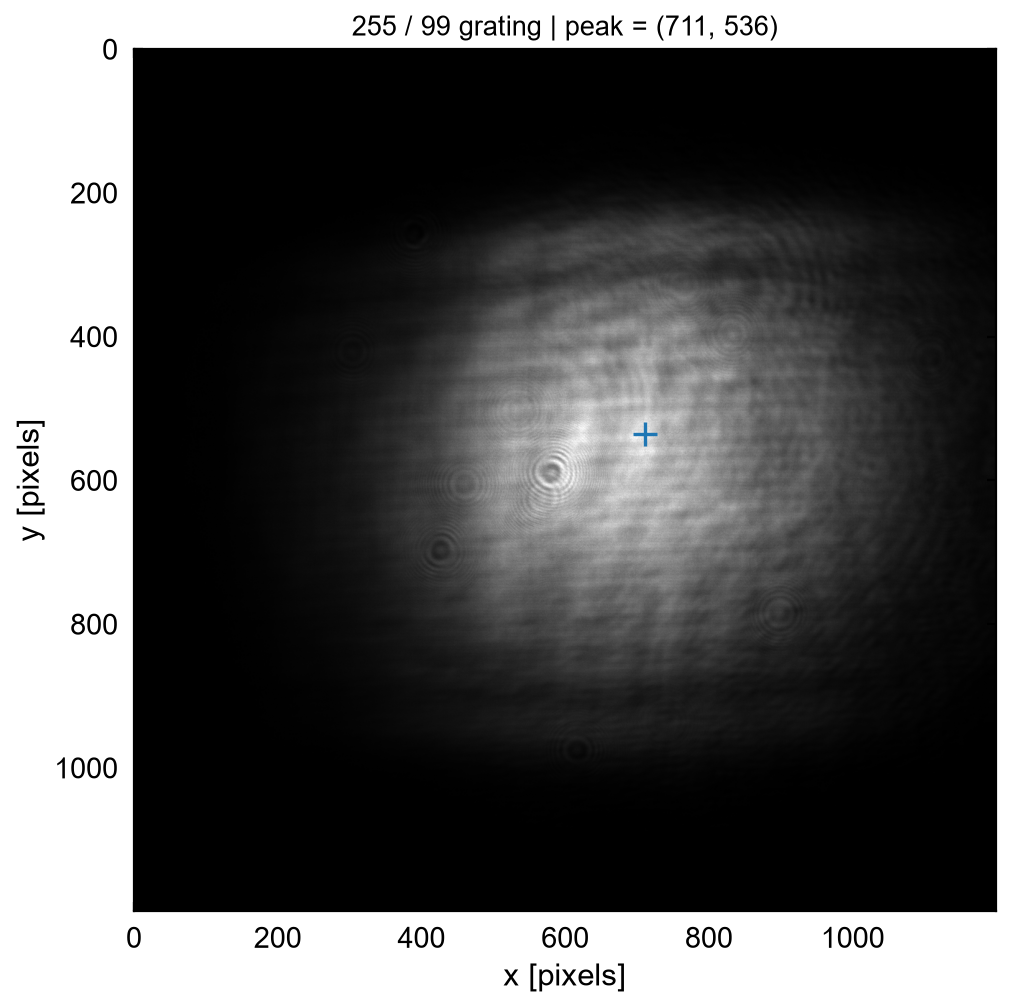

In [43]:
# Cell 10 — Check likely maximum at gray = 99

TEST_GRAY = 99

ny, nx = slm.shape
x = np.arange(nx)

stripe_line = np.where(
    (x // PIXELS_PER_STRIPE) % 2 == 0,
    REFERENCE_GRAY,
    TEST_GRAY,
).astype(np.uint8)

pattern_99 = np.tile(stripe_line, (ny, 1))

slm.set_phase(pattern_99, settle=True)

image_99 = cam.get_image(
    timeout_s=3,
    transform=False,
)

peak_y, peak_x = np.unravel_index(
    np.argmax(image_99),
    image_99.shape
)

print("=== Gray 99 check ===")
print("Image shape          :", image_99.shape)
print("Peak position (x, y) :", (peak_x, peak_y))
print("Peak value           :", image_99[peak_y, peak_x])
print("Pixels at 255        :", np.count_nonzero(image_99 == 255))

plt.figure(figsize=(7, 7))
plt.imshow(image_99, cmap="gray", vmin=0, vmax=255)
plt.scatter(peak_x, peak_y, marker="+", s=120)
plt.title(f"255 / 99 grating | peak = ({peak_x}, {peak_y})")
plt.xlabel("x [pixels]")
plt.ylabel("y [pixels]")
plt.show()

In [52]:
# Reduce exposure for LUT calibration

cam.set_exposure(80e-6)   # 80 us

print("Actual exposure [us]:", cam.get_exposure() * 1e6)

Actual exposure [us]: 84.681


In [53]:
# Re-check gray 99 after reducing exposure

image_99 = cam.get_image(
    timeout_s=3,
    transform=False,
)

peak_y, peak_x = np.unravel_index(
    np.argmax(image_99),
    image_99.shape
)

print("=== Gray 99 exposure check ===")
print("Peak position (x, y) :", (peak_x, peak_y))
print("Peak value           :", image_99[peak_y, peak_x])
print("Pixels at 255        :", np.count_nonzero(image_99 == 255))

=== Gray 99 exposure check ===
Peak position (x, y) : (np.int64(601), np.int64(600))
Peak value           : 221
Pixels at 255        : 0


In [54]:
# Cell 10B — Explicitly confirm exposure + gray-99 result

actual_exposure_us = cam.get_exposure() * 1e6

image_99 = cam.get_image(
    timeout_s=3,
    transform=False,
)

peak_y, peak_x = np.unravel_index(
    np.argmax(image_99),
    image_99.shape
)

peak_value = int(image_99[peak_y, peak_x])
n_sat = int(np.count_nonzero(image_99 == 255))

print("=== Final gray-99 calibration check ===")
print(f"Actual exposure [us] : {actual_exposure_us:.3f}")
print("Image shape          :", image_99.shape)
print("Peak position (x, y) :", (peak_x, peak_y))
print("Peak value           :", peak_value)
print("Pixels at 255        :", n_sat)

if n_sat == 0:
    print("\nPASS: no saturated pixels.")
else:
    print("\nWARNING: saturation detected.")

=== Final gray-99 calibration check ===
Actual exposure [us] : 84.681
Image shape          : (1200, 1200)
Peak position (x, y) : (np.int64(601), np.int64(600))
Peak value           : 223
Pixels at 255        : 0

PASS: no saturated pixels.


=== LUT scan settings ===
Exposure [us]       : 84.681
Camera image shape  : (1200, 1200)
Spot center (x, y)  : (601, 600)
Signal half-width   : 450
Background border   : 80
Save directory      : c:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\Experiment scripts\LUT_locked_759nm_20260811_201109

[  1/256] gray=255 | P=        14.0 | peak=  1 | sat=  0 | t=   0.5 s
[  2/256] gray=254 | P=        11.0 | peak=  2 | sat=  0 | t=   1.0 s
[  3/256] gray=253 | P=         3.0 | peak=  2 | sat=  0 | t=   1.6 s
[  4/256] gray=252 | P=         5.0 | peak=  2 | sat=  0 | t=   2.1 s
[  5/256] gray=251 | P=         9.0 | peak=  2 | sat=  0 | t=   2.6 s
[  6/256] gray=250 | P=         7.0 | peak=  2 | sat=  0 | t=   3.1 s
[  7/256] gray=249 | P=         9.0 | peak=  1 | sat=  0 | t=   3.7 s
[  8/256] gray=248 | P=         4.0 | peak=  1 | sat=  0 | t=   4.2 s
[  9/256] gray=247 | P=         5.0 | peak=  2 | sat=  0 | t=   4.7 s
[ 10/256] gray=246 | P=         6.0 | peak=  2 | sat=  0 | t=   5.2

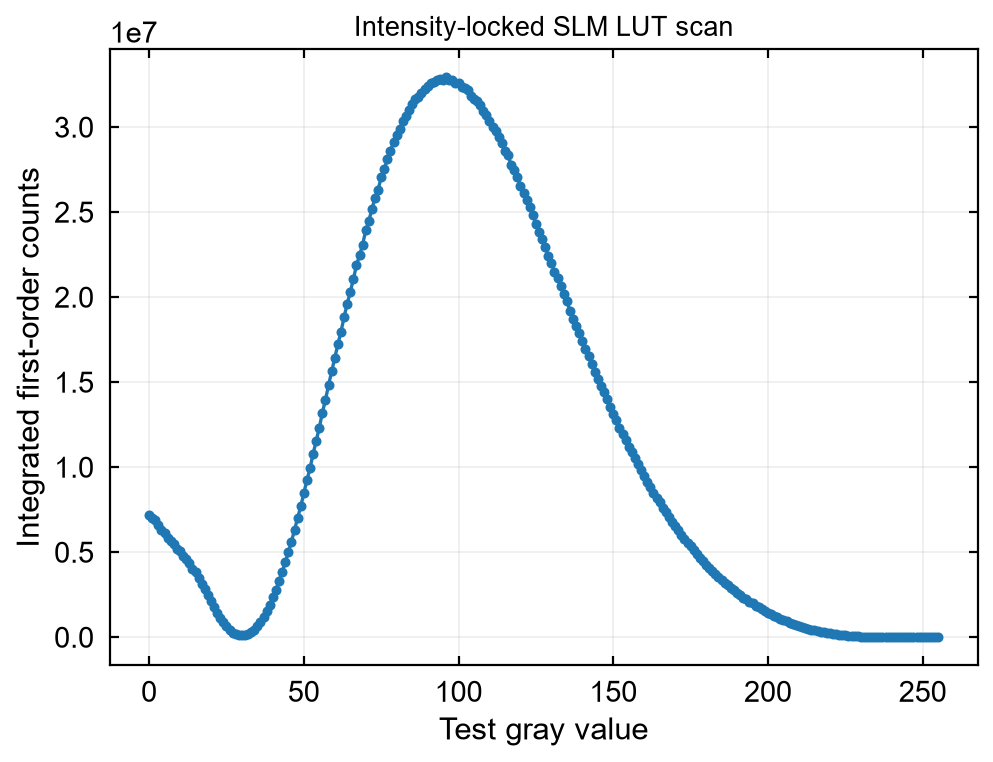


=== Scan complete ===
Total time : 135.3 s
CSV saved  : c:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\Experiment scripts\LUT_locked_759nm_20260811_201109\lut_scan.csv


In [55]:
# Cell 11 — Fast 256-point LUT scan with intensity-locked laser

import csv
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Fixed scan parameters
# ------------------------------------------------------------

TEST_GRAYS = np.arange(255, -1, -1, dtype=int)

CX = 601
CY = 600

SIGNAL_HALF_WIDTH = 450
BACKGROUND_BORDER = 80

ny, nx = slm.shape
x = np.arange(nx)


def make_binary_grating(test_gray):
    stripe_line = np.where(
        (x // PIXELS_PER_STRIPE) % 2 == 0,
        REFERENCE_GRAY,
        test_gray,
    ).astype(np.uint8)

    return np.tile(stripe_line, (ny, 1))


def estimate_background(img):
    b = BACKGROUND_BORDER

    border = np.concatenate([
        img[:b, :].ravel(),
        img[-b:, :].ravel(),
        img[b:-b, :b].ravel(),
        img[b:-b, -b:].ravel(),
    ])

    return float(np.median(border))


def integrated_power(img, background):
    x0 = CX - SIGNAL_HALF_WIDTH
    x1 = CX + SIGNAL_HALF_WIDTH
    y0 = CY - SIGNAL_HALF_WIDTH
    y1 = CY + SIGNAL_HALF_WIDTH

    signal = img[y0:y1, x0:x1].astype(np.float64)

    return float(np.sum(signal - background))


# ------------------------------------------------------------
# Save folder
# ------------------------------------------------------------

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

SAVE_DIR = Path.cwd() / f"LUT_locked_759nm_{timestamp}"
SAVE_DIR.mkdir(parents=True, exist_ok=False)

CSV_PATH = SAVE_DIR / "lut_scan.csv"


print("=== LUT scan settings ===")
print(f"Exposure [us]       : {cam.get_exposure() * 1e6:.3f}")
print("Camera image shape  :", image_99.shape)
print("Spot center (x, y)  :", (CX, CY))
print("Signal half-width   :", SIGNAL_HALF_WIDTH)
print("Background border   :", BACKGROUND_BORDER)
print("Save directory      :", SAVE_DIR)
print()


# ------------------------------------------------------------
# Scan
# ------------------------------------------------------------

rows = []

scan_start = time.perf_counter()

for i, gray in enumerate(TEST_GRAYS):

    pattern = make_binary_grating(gray)

    slm.set_phase(
        pattern,
        settle=True,
    )

    img = cam.get_image(
        timeout_s=3,
        transform=False,
    )

    background = estimate_background(img)
    power = integrated_power(img, background)

    peak = int(img.max())
    saturated = int(np.count_nonzero(img == 255))

    elapsed = time.perf_counter() - scan_start

    rows.append({
        "gray": int(gray),
        "time_s": elapsed,
        "power": power,
        "background": background,
        "peak": peak,
        "saturated": saturated,
    })

    print(
        f"[{i+1:3d}/256] "
        f"gray={gray:3d} | "
        f"P={power:12.1f} | "
        f"peak={peak:3d} | "
        f"sat={saturated:3d} | "
        f"t={elapsed:6.1f} s"
    )

    if saturated > 0:
        raise RuntimeError(
            f"Saturation detected at gray {gray}."
        )


# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

with open(CSV_PATH, "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "gray",
            "time_s",
            "power",
            "background",
            "peak",
            "saturated",
        ],
    )

    writer.writeheader()
    writer.writerows(rows)


# ------------------------------------------------------------
# Plot response
# ------------------------------------------------------------

grays = np.array([r["gray"] for r in rows])
powers = np.array([r["power"] for r in rows])

order = np.argsort(grays)

plt.figure(figsize=(7, 5))
plt.plot(
    grays[order],
    powers[order],
    ".-",
)

plt.xlabel("Test gray value")
plt.ylabel("Integrated first-order counts")
plt.title("Intensity-locked SLM LUT scan")
plt.grid(alpha=0.2)
plt.show()


total_time = time.perf_counter() - scan_start

print()
print("=== Scan complete ===")
print(f"Total time : {total_time:.1f} s")
print("CSV saved  :", CSV_PATH)

In [56]:
# Cell 12 — Inspect existing Meadowlark LUT file formats
# READ-ONLY: nothing is changed.

def inspect_lut_file(path, name):
    path = Path(path)

    print(f"\n{'='*70}")
    print(name)
    print("="*70)
    print("Path :", path)
    print("Size :", path.stat().st_size, "bytes")

    raw = path.read_bytes()

    print("\nFirst 64 raw bytes:")
    print(raw[:64])

    try:
        text = raw.decode("utf-8")
        lines = text.splitlines()

        print("\nFile decodes as UTF-8 text.")
        print("Number of lines:", len(lines))

        print("\nFirst 20 lines:")
        for i, line in enumerate(lines[:20]):
            print(f"{i:3d}: {repr(line)}")

        print("\nLast 10 lines:")
        start = max(0, len(lines) - 10)

        for i, line in enumerate(lines[start:], start=start):
            print(f"{i:3d}: {repr(line)}")

    except UnicodeDecodeError:
        print("\nFile does NOT appear to be plain UTF-8 text.")

        print("\nFirst 128 bytes as hex:")
        print(raw[:128].hex(" "))


inspect_lut_file(
    LINEAR_LUT_PATH,
    "Meadowlark 8-bit linear-voltage LUT"
)

inspect_lut_file(
    FAN_LUT_PATH,
    "Fan's 759-nm LUT"
)


Meadowlark 8-bit linear-voltage LUT
Path : C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\LUT Files\19x12_8bit_linearVoltage.lut
Size : 2379 bytes

First 64 raw bytes:
b'0\t0\r\n1\t16\r\n2\t32\r\n3\t48\r\n4\t64\r\n5\t80\r\n6\t96\r\n7\t112\r\n8\t128\r\n9\t144\r\n10'

File decodes as UTF-8 text.
Number of lines: 256

First 20 lines:
  0: '0\t0'
  1: '1\t16'
  2: '2\t32'
  3: '3\t48'
  4: '4\t64'
  5: '5\t80'
  6: '6\t96'
  7: '7\t112'
  8: '8\t128'
  9: '9\t144'
 10: '10\t160'
 11: '11\t176'
 12: '12\t192'
 13: '13\t208'
 14: '14\t224'
 15: '15\t240'
 16: '16\t256'
 17: '17\t272'
 18: '18\t288'
 19: '19\t304'

Last 10 lines:
246: '246\t3936'
247: '247\t3952'
248: '248\t3968'
249: '249\t3984'
250: '250\t4000'
251: '251\t4016'
252: '252\t4032'
253: '253\t4048'
254: '254\t4064'
255: '255\t4080'

Fan's 759-nm LUT
Path : C:\Users\admin\Desktop\Projects\SLM\LUT from Fan\759nm_roomtemp_global\759nm_roomtemp_global\759nm_rommtemp_global.lut
Size : 2421 bytes

First 64 raw bytes:
b'0 850\r\n

=== Phase landmarks from fresh measurement ===
0 phase  : gray = 255, I = 12.6
pi phase : gray = 95, I = 32834035.8
2pi phase: gray = 30, I = 105459.7


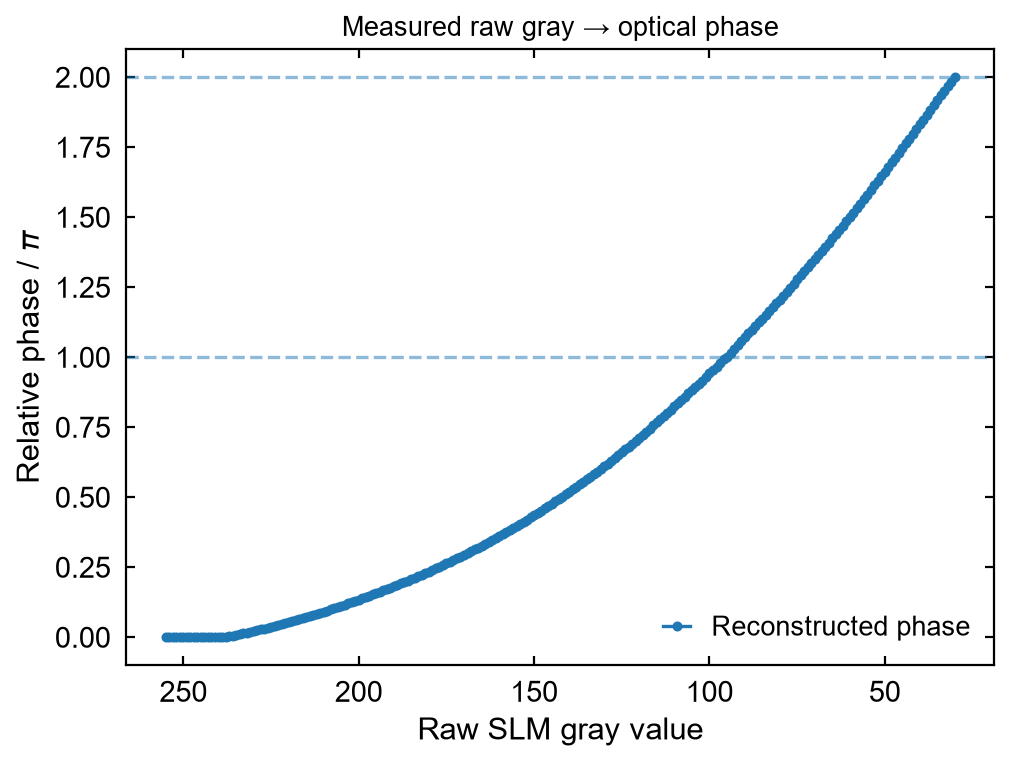

In [58]:
# Cell 12 — Reconstruct optical phase from measured diffraction intensity

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter


# ------------------------------------------------------------
# Load today's fresh scan
# CSV_PATH already exists from the scan cell
# ------------------------------------------------------------

df = pd.read_csv(CSV_PATH)

gray = df["gray"].to_numpy(dtype=float)
power = df["power"].to_numpy(dtype=float)

# Sort from bright SLM gray -> dark SLM gray:
# 255, 254, ..., 0
order = np.argsort(gray)[::-1]

g = gray[order]
I = power[order]


# ------------------------------------------------------------
# Smooth only enough to suppress point-to-point camera noise.
# We are NOT fitting a physical model yet.
# ------------------------------------------------------------

I_smooth = savgol_filter(
    I,
    window_length=11,
    polyorder=3,
)


# ------------------------------------------------------------
# Restrict to the useful first 0 -> 2pi phase cycle.
# First find the first maximum.
# ------------------------------------------------------------

# Search approximately where we know the first maximum lives.
peak_mask = (g >= 70) & (g <= 130)

peak_index_local = np.argmax(I_smooth[peak_mask])
peak_indices = np.where(peak_mask)[0]
i_pi = peak_indices[peak_index_local]

g_pi = g[i_pi]
I_pi = I_smooth[i_pi]


# ------------------------------------------------------------
# Find the second minimum after the maximum
# Search around the observed ~30 gray region.
# ------------------------------------------------------------

min_mask = (g >= 20) & (g <= 45)

min_index_local = np.argmin(I_smooth[min_mask])
min_indices = np.where(min_mask)[0]
i_2pi = min_indices[min_index_local]

g_2pi = g[i_2pi]
I_2pi = I_smooth[i_2pi]


# 0-phase endpoint is raw gray 255.
i_zero = np.argmin(np.abs(g - 255))
g_zero = g[i_zero]
I_zero = I_smooth[i_zero]


print("=== Phase landmarks from fresh measurement ===")
print(f"0 phase  : gray = {g_zero:.0f}, I = {I_zero:.1f}")
print(f"pi phase : gray = {g_pi:.0f}, I = {I_pi:.1f}")
print(f"2pi phase: gray = {g_2pi:.0f}, I = {I_2pi:.1f}")


# ------------------------------------------------------------
# Reconstruct phase branch-by-branch.
#
# Binary grating:
#
#       I ∝ sin²(Δphi / 2)
#
# Branch 1: 0 -> pi
# Branch 2: pi -> 2pi
#
# Each branch gets its own measured minimum so that:
# gray 255 -> exactly 0
# maximum  -> exactly pi
# gray ~30 -> exactly 2pi
# ------------------------------------------------------------

use = (g <= g_zero) & (g >= g_2pi)

g_use = g[use]
I_use = I_smooth[use]

phi = np.full_like(g_use, np.nan, dtype=float)


# Location of pi point inside g_use.
j_pi = np.argmin(np.abs(g_use - g_pi))


# ----- Branch 1: 0 -> pi -----

I1 = I_use[:j_pi + 1]

norm1 = (I1 - I_zero) / (I_pi - I_zero)
norm1 = np.clip(norm1, 0.0, 1.0)

phi[:j_pi + 1] = 2 * np.arcsin(np.sqrt(norm1))


# ----- Branch 2: pi -> 2pi -----

I2 = I_use[j_pi:]

norm2 = (I2 - I_2pi) / (I_pi - I_2pi)
norm2 = np.clip(norm2, 0.0, 1.0)

phi[j_pi:] = (
    2 * np.pi
    - 2 * np.arcsin(np.sqrt(norm2))
)


# ------------------------------------------------------------
# Enforce strict physical monotonicity.
# As raw gray decreases, phase must increase.
# Small residual experimental wiggles are removed.
# ------------------------------------------------------------

phi_monotonic = np.maximum.accumulate(phi)


# Force exact endpoints.
phi_monotonic[0] = 0.0
phi_monotonic[-1] = 2 * np.pi


# ------------------------------------------------------------
# Plot reconstructed phase
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    g_use,
    phi_monotonic / np.pi,
    ".-",
    label="Reconstructed phase",
)

plt.axhline(1, linestyle="--", alpha=0.5)
plt.axhline(2, linestyle="--", alpha=0.5)

plt.xlabel("Raw SLM gray value")
plt.ylabel(r"Relative phase / $\pi$")
plt.title("Measured raw gray → optical phase")

plt.gca().invert_xaxis()
plt.legend()
plt.show()

=== Candidate LUT diagnostics ===
Number of entries : 256
Drive minimum     : 487
Drive maximum     : 4080
Monotonic drive   : True

Selected LUT entries:
  0 -> raw gray   30.467 -> drive  487 -> target phase  1.9922 pi
  1 -> raw gray   30.933 -> drive  495 -> target phase  1.9844 pi
 32 -> raw gray   45.282 -> drive  725 -> target phase  1.7422 pi
 64 -> raw gray   60.552 -> drive  969 -> target phase  1.4922 pi
 96 -> raw gray   77.436 -> drive 1239 -> target phase  1.2422 pi
127 -> raw gray   95.000 -> drive 1520 -> target phase  1.0000 pi
128 -> raw gray   96.096 -> drive 1538 -> target phase  0.9922 pi
160 -> raw gray  117.284 -> drive 1877 -> target phase  0.7422 pi
192 -> raw gray  143.133 -> drive 2290 -> target phase  0.4922 pi
224 -> raw gray  178.698 -> drive 2859 -> target phase  0.2422 pi
254 -> raw gray  235.015 -> drive 3760 -> target phase  0.0078 pi
255 -> raw gray  255.000 -> drive 4080 -> target phase  0.0000 pi


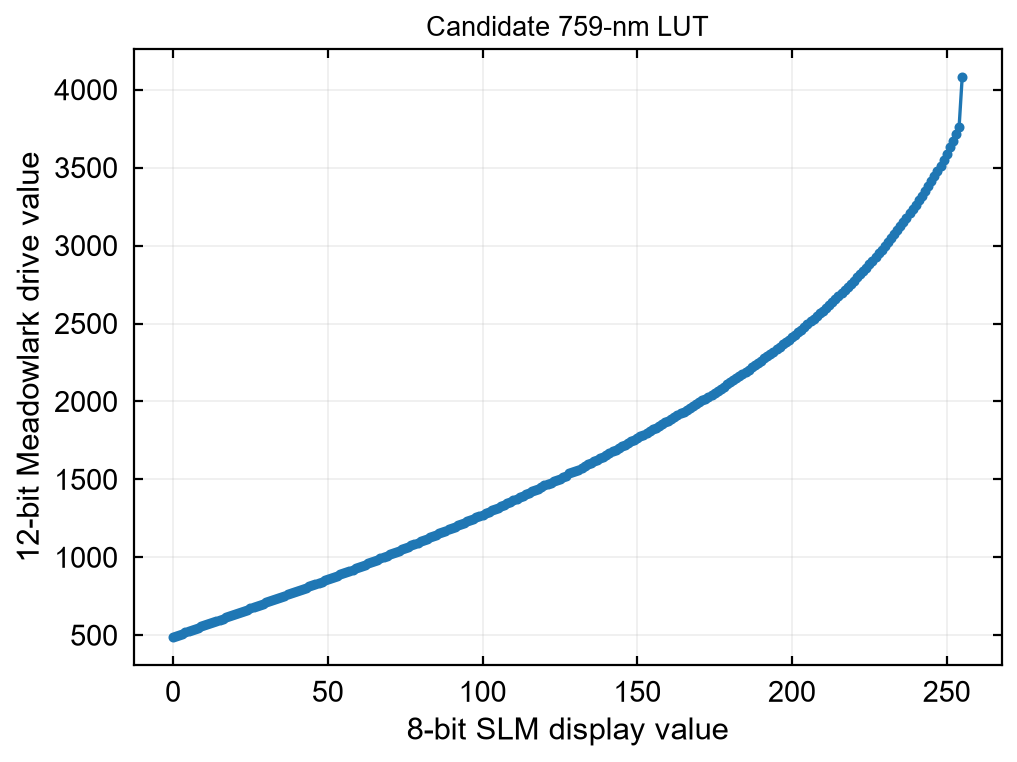

In [59]:
# Cell 13 — Build candidate Meadowlark LUT from reconstructed phase
# Does NOT modify the SLM yet.

# ------------------------------------------------------------
# 1. Remove duplicate phase values from the reconstructed curve.
#
# phi_monotonic increases as raw gray decreases:
# raw gray ~255 -> phase 0
# raw gray ~30  -> phase 2pi
# ------------------------------------------------------------

phi_unique, unique_idx = np.unique(
    phi_monotonic,
    return_index=True
)

gray_unique = g_use[unique_idx]


# ------------------------------------------------------------
# 2. Desired phase associated with each 8-bit SLM display value.
#
# This follows slmsuite 0.4.1's 256-level convention:
#
# display 255 -> phase 0
# display 254 -> phase 2pi/256
# ...
# display   0 -> phase 255*2pi/256
# ------------------------------------------------------------

lut_index = np.arange(256, dtype=int)

desired_phase = (
    (255 - lut_index)
    * 2 * np.pi
    / 256
)


# ------------------------------------------------------------
# 3. Invert measured phase(raw_gray)
#
# Find the equivalent raw gray required to produce
# each desired phase.
# ------------------------------------------------------------

required_raw_gray = np.interp(
    desired_phase,
    phi_unique,
    gray_unique
)


# Explicitly enforce phase-zero endpoint.
required_raw_gray[-1] = 255.0


# ------------------------------------------------------------
# 4. Convert raw gray into Meadowlark's 12-bit drive value.
#
# Factory linear LUT showed:
# raw gray 0   -> drive 0
# raw gray 1   -> drive 16
# ...
# raw gray 255 -> drive 4080
# ------------------------------------------------------------

lut_drive = np.rint(
    16 * required_raw_gray
).astype(int)

lut_drive = np.clip(
    lut_drive,
    0,
    4095
)


# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

print("=== Candidate LUT diagnostics ===")
print("Number of entries :", len(lut_drive))
print("Drive minimum     :", lut_drive.min())
print("Drive maximum     :", lut_drive.max())
print(
    "Monotonic drive   :",
    np.all(np.diff(lut_drive) >= 0)
)

print("\nSelected LUT entries:")
for q in [0, 1, 32, 64, 96, 127, 128, 160, 192, 224, 254, 255]:
    print(
        f"{q:3d} -> "
        f"raw gray {required_raw_gray[q]:8.3f} -> "
        f"drive {lut_drive[q]:4d} -> "
        f"target phase {desired_phase[q]/np.pi:7.4f} pi"
    )


# ------------------------------------------------------------
# Plot candidate LUT
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    lut_index,
    lut_drive,
    ".-",
)

plt.xlabel("8-bit SLM display value")
plt.ylabel("12-bit Meadowlark drive value")
plt.title("Candidate 759-nm LUT")

plt.grid(alpha=0.2)
plt.show()

In [60]:
# Cell 14 — Save candidate LUT as a new Meadowlark .lut file
# Does NOT overwrite Fan's LUT or the factory linear LUT.

from datetime import datetime
from pathlib import Path


# Save beside today's calibration data
NEW_LUT_PATH = SAVE_DIR / "759nm_KS_global_20260811.lut"


# Meadowlark format:
# LUT index <whitespace> 12-bit drive value
#
# Example:
# 0 487
# 1 495
# ...
# 255 4080

with open(NEW_LUT_PATH, "w", newline="") as f:
    for q, drive in zip(lut_index, lut_drive):
        f.write(f"{int(q)} {int(drive)}\r\n")


print("=== New LUT written ===")
print("Path           :", NEW_LUT_PATH)
print("Entries        :", len(lut_drive))
print("File exists    :", NEW_LUT_PATH.exists())
print("File size [B]  :", NEW_LUT_PATH.stat().st_size)

print("\nFirst 10 entries:")
for q in range(10):
    print(f"{q:3d} {lut_drive[q]:4d}")

print("\nMiddle entries:")
for q in range(123, 132):
    print(f"{q:3d} {lut_drive[q]:4d}")

print("\nLast 10 entries:")
for q in range(246, 256):
    print(f"{q:3d} {lut_drive[q]:4d}")

=== New LUT written ===
Path           : c:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\Experiment scripts\LUT_locked_759nm_20260811_201109\759nm_KS_global_20260811.lut
Entries        : 256
File exists    : True
File size [B]  : 2382

First 10 entries:
  0  487
  1  495
  2  503
  3  510
  4  518
  5  526
  6  534
  7  542
  8  549
  9  557

Middle entries:
123 1487
124 1496
125 1504
126 1512
127 1520
128 1538
129 1546
130 1554
131 1563

Last 10 entries:
246 3444
247 3477
248 3512
249 3549
250 3588
251 3630
252 3674
253 3716
254 3760
255 4080


In [61]:
# Cell 15 — Load our new 759-nm LUT
# Keep the existing SLM object; do NOT reinitialize Meadowlark.

slm.load_lut(str(NEW_LUT_PATH))

# Put SLM into a known uniform zero-phase command afterward.
uniform_255 = np.full(
    slm.shape,
    255,
    dtype=np.uint8,
)

slm.set_phase(
    uniform_255,
    settle=True,
)

print("=== New LUT loaded ===")
print("LUT :", NEW_LUT_PATH)
print("SLM display values:", np.unique(slm.display))
print()
print("Ready for LUT verification.")

=== New LUT loaded ===
LUT : c:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\Experiment scripts\LUT_locked_759nm_20260811_201109\759nm_KS_global_20260811.lut
SLM display values: [255]

Ready for LUT verification.


In [62]:
# Cell 16 — Three-point verification of the new LUT

VERIFY_GRAYS = [255, 127, 0]

verification = []

for test_gray in VERIFY_GRAYS:

    # Build binary stripe pattern:
    # reference stripes = 255
    # test stripes      = selected display value
    pattern = make_binary_grating(test_gray)

    slm.set_phase(
        pattern,
        settle=True,
    )

    img = cam.get_image(
        timeout_s=3,
        transform=False,
    )

    background = estimate_background(img)
    power = integrated_power(img, background)

    peak = int(img.max())
    saturated = int(np.count_nonzero(img == 255))

    verification.append({
        "gray": test_gray,
        "power": power,
        "peak": peak,
        "saturated": saturated,
    })

    print(
        f"gray={test_gray:3d} | "
        f"P={power:12.1f} | "
        f"peak={peak:3d} | "
        f"sat={saturated}"
    )


# Normalize to the gray-127 value
P127 = next(v["power"] for v in verification if v["gray"] == 127)

print("\n=== Normalized to gray 127 ===")

for v in verification:
    print(
        f"gray={v['gray']:3d} | "
        f"P/P127 = {v['power']/P127:.6f}"
    )

gray=255 | P=        13.0 | peak=  1 | sat=0
gray=127 | P=  32731192.0 | peak=218 | sat=0
gray=  0 | P=    110481.0 | peak=  5 | sat=0

=== Normalized to gray 127 ===
gray=255 | P/P127 = 0.000000
gray=127 | P/P127 = 1.000000
gray=  0 | P/P127 = 0.003375


=== New LUT verification scan ===
Exposure [us]      : 84.681
Camera image shape : (1200, 1200)
Spot center        : (601, 600)
Save directory     : c:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\Experiment scripts\LUT_locked_759nm_20260811_201109\verification_new_LUT_20260811_203519

[  1/256] gray=255 | P=        19.0 | peak=  1 | sat=  0 | t=   0.6 s
[  2/256] gray=254 | P=      5108.0 | peak=  2 | sat=  0 | t=   1.1 s
[  3/256] gray=253 | P=     18738.0 | peak=  2 | sat=  0 | t=   1.7 s
[  4/256] gray=252 | P=     47812.0 | peak=  2 | sat=  0 | t=   2.2 s
[  5/256] gray=251 | P=     82643.0 | peak=  2 | sat=  0 | t=   2.7 s
[  6/256] gray=250 | P=    123286.0 | peak=  3 | sat=  0 | t=   3.2 s
[  7/256] gray=249 | P=    180092.0 | peak=  4 | sat=  0 | t=   3.8 s
[  8/256] gray=248 | P=    248729.0 | peak=  5 | sat=  0 | t=   4.3 s
[  9/256] gray=247 | P=    320486.0 | peak=  6 | sat=  0 | t=   4.8 s
[ 10/256] gray=246 | P=    400785.0 | peak=  6 | sat=  0 | t=   5.4 s
[ 11/25

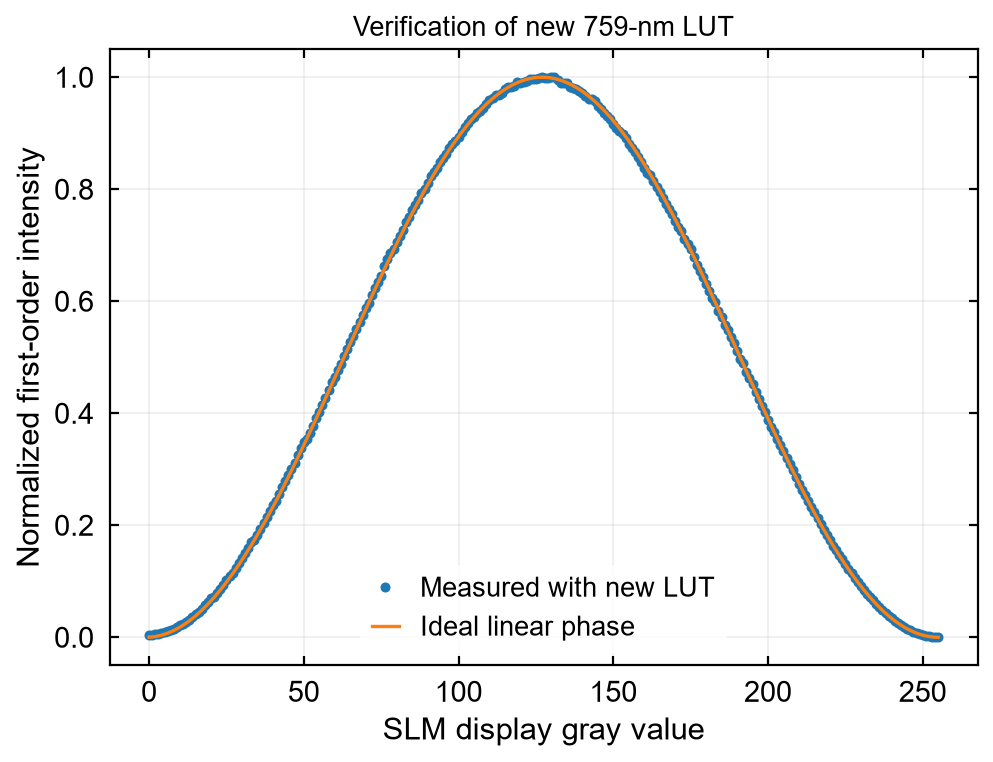


=== Verification summary ===
Measured maximum at gray : 131
Maximum integrated power : 32856341.0
P(gray 255) / Pmax       : 5.78274981989017e-07
P(gray 0) / Pmax         : 0.0034635323513351655
Total time                : 134.1 s
CSV saved                 : c:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\Experiment scripts\LUT_locked_759nm_20260811_201109\verification_new_LUT_20260811_203519\new_LUT_verification.csv


In [63]:
# Cell 17 — Full 256-point verification of the NEW LUT

import csv
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Verification settings
# ------------------------------------------------------------

VERIFY_GRAYS = np.arange(255, -1, -1, dtype=int)

verify_rows = []

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

VERIFY_DIR = SAVE_DIR / f"verification_new_LUT_{timestamp}"
VERIFY_DIR.mkdir(parents=True, exist_ok=False)

VERIFY_CSV = VERIFY_DIR / "new_LUT_verification.csv"


print("=== New LUT verification scan ===")
print(f"Exposure [us]      : {cam.get_exposure() * 1e6:.3f}")
print("Camera image shape :", image_99.shape)
print("Spot center        :", (CX, CY))
print("Save directory     :", VERIFY_DIR)
print()


# ------------------------------------------------------------
# Scan
# ------------------------------------------------------------

t0 = time.perf_counter()

for i, test_gray in enumerate(VERIFY_GRAYS):

    pattern = make_binary_grating(test_gray)

    slm.set_phase(
        pattern,
        settle=True,
    )

    img = cam.get_image(
        timeout_s=3,
        transform=False,
    )

    background = estimate_background(img)
    power = integrated_power(img, background)

    peak = int(img.max())
    saturated = int(np.count_nonzero(img == 255))

    elapsed = time.perf_counter() - t0

    verify_rows.append({
        "gray": int(test_gray),
        "time_s": elapsed,
        "power": power,
        "background": background,
        "peak": peak,
        "saturated": saturated,
    })

    print(
        f"[{i+1:3d}/256] "
        f"gray={test_gray:3d} | "
        f"P={power:12.1f} | "
        f"peak={peak:3d} | "
        f"sat={saturated:3d} | "
        f"t={elapsed:6.1f} s"
    )

    if saturated > 0:
        raise RuntimeError(
            f"Saturation detected at display gray {test_gray}."
        )


# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

with open(VERIFY_CSV, "w", newline="") as f:

    writer = csv.DictWriter(
        f,
        fieldnames=[
            "gray",
            "time_s",
            "power",
            "background",
            "peak",
            "saturated",
        ],
    )

    writer.writeheader()
    writer.writerows(verify_rows)


# ------------------------------------------------------------
# Prepare measured curve
# ------------------------------------------------------------

g_verify = np.array(
    [r["gray"] for r in verify_rows],
    dtype=float,
)

P_verify = np.array(
    [r["power"] for r in verify_rows],
    dtype=float,
)

# Normalize measured curve
P_norm = P_verify / np.max(P_verify)


# ------------------------------------------------------------
# Ideal response expected from a perfectly linear LUT
#
# delta_phi = (255 - gray) * 2pi / 256
# I(+/-1) ∝ sin²(delta_phi / 2)
# ------------------------------------------------------------

phi_ideal = (
    (255 - g_verify)
    * 2 * np.pi
    / 256
)

I_ideal = np.sin(phi_ideal / 2) ** 2


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

sort_idx = np.argsort(g_verify)

plt.figure(figsize=(7, 5))

plt.plot(
    g_verify[sort_idx],
    P_norm[sort_idx],
    ".",
    label="Measured with new LUT",
)

plt.plot(
    g_verify[sort_idx],
    I_ideal[sort_idx],
    "-",
    label="Ideal linear phase",
)

plt.xlabel("SLM display gray value")
plt.ylabel("Normalized first-order intensity")
plt.title("Verification of new 759-nm LUT")

plt.legend()
plt.grid(alpha=0.2)

plt.show()


# ------------------------------------------------------------
# Simple diagnostics
# ------------------------------------------------------------

imax = np.argmax(P_verify)

print()
print("=== Verification summary ===")
print(
    "Measured maximum at gray :",
    int(g_verify[imax]),
)
print(
    "Maximum integrated power :",
    P_verify[imax],
)

print(
    "P(gray 255) / Pmax       :",
    P_verify[g_verify == 255][0] / P_verify[imax],
)

print(
    "P(gray 0) / Pmax         :",
    P_verify[g_verify == 0][0] / P_verify[imax],
)

print(
    f"Total time                : "
    f"{time.perf_counter() - t0:.1f} s"
)

print("CSV saved                 :", VERIFY_CSV)

In [64]:
slm.close_sdk()